In [4]:
import tqdm
import pandas
import joblib
import sklearn.compose
import sklearn.preprocessing
import sklearn.model_selection
import matplotlib.pyplot as plt

from lazyfca import LazyFCA

from utils import estimate_quality

In [5]:
data = pandas.read_csv("churn.csv")
data = data.drop(columns = ['customerID'])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

X = data.drop(columns = ["Churn"])
# y = data["Churn"].to_numpy()
y = (data["Churn"] == "Yes").to_numpy()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))
ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool'), categorical)
    ]
)
X_train = pandas.DataFrame(ct.fit_transform(X_train), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(ct.transform(X_test), columns = ct.get_feature_names_out())

categorical = [ feature for feature in ct.get_feature_names_out() if feature.startswith("categorical__") ]
X_train[categorical] = X_train[categorical].astype(bool)
X_test[categorical] = X_test[categorical].astype(bool)

y_train = pandas.Series(y_train)
y_test = pandas.Series(y_test)

In [6]:
classifier = LazyFCA(
    pos_params=LazyFCA.Params(
        supporters_covered=5,
        supporter_opposer_ratio=1 / 2.75,
        matthews_correlation=0.1
    ),
    neg_params=LazyFCA.Params(
        supporters_covered=10,
        supporter_opposer_ratio=4,
        lift=1.5,
        matthews_correlation=0.05
    ),
    pos_weight=1.0
)
classifier.fit(X_train, y_train)

In [23]:
y_pred = classifier.predict(X_test)
estimate_quality(y_pred, y_test)['total']

100%|██████████| 704/704 [01:32<00:00,  7.63it/s]


{'Accuracy': 0.3409090909090909,
 'Precision': 0.28659476117103233,
 'Recall': 0.9946524064171123,
 'AUC-ROC': 0.5495505745818637,
 'F1-score': 0.4449760765550239,
 'True Positive': np.int64(186),
 'True Negative': np.int64(54),
 'False Positive': np.int64(463),
 'False Negative': np.int64(1),
 'True Negative Rate (Specificity)': np.float64(0.10444874274661509),
 'Negative Predictive Value': np.float64(0.9818181818181818),
 'False Positive Rate': np.float64(0.8955512572533849),
 'False Discovery Rate': np.float64(0.7134052388289677),
 'Balanced precision proxy': np.float64(0.09910114916372736),
 "Youden's J": np.float64(0.09910114916372736),
 'Matthews correlation': 0.16309515964813048}

In [10]:
classifier.explain(X_test.iloc[52]).display()

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
0,0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,258,128,2.015625,0.153389,0.027551,0.668394,2.514623,0.024558,0.125838,0.125838,0.232276,0.314738,0.030814,2.011673,1209.100791,-1219.826782
1,0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,133,81,1.641975,0.079073,0.017434,0.621495,2.338182,0.012029,0.061638,0.061638,0.150637,0.217919,0.028312,1.638037,1427.928829,-835.525202
2,0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,125,52,2.403846,0.074316,0.011192,0.706215,2.656912,0.012319,0.063124,0.063124,0.169117,0.204309,0.016737,2.390476,1441.871542,-753.272086
3,0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,285,136,2.095588,0.169441,0.029272,0.676960,2.546849,0.027354,0.140169,0.140169,0.248473,0.329640,0.028978,2.091575,1164.271784,-1279.871823
4,0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,271,132,2.053030,0.161118,0.028412,0.672457,2.529908,0.025898,0.132706,0.132706,0.240075,0.322144,0.030057,2.049057,1187.413224,-1249.699697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,378,251,1.505976,0.224732,0.054025,0.600954,2.260901,0.033314,0.170707,0.170707,0.252046,0.388029,0.054627,1.504970,1024.509137,-1616.779269
264,0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,509,467,1.089936,0.302616,0.100517,0.521516,1.962043,0.039440,0.202099,0.202099,0.247192,0.457001,0.099353,1.089840,864.972750,-2102.207871
265,0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,256,290,0.882759,0.152200,0.062419,0.468864,1.763956,0.017521,0.089780,0.089780,0.141253,0.346955,0.097778,0.882960,1227.064732,-1525.380999
266,0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,127,78,1.628205,0.075505,0.016789,0.619512,2.330721,0.011459,0.058717,0.058717,0.146506,0.211719,0.027594,1.624204,1438.898693,-810.905242


In [11]:
def explain(item):
    return classifier.explain(item).display()

scores = joblib.Parallel(n_jobs = -1)(
    joblib.delayed(explain)(item)
    for _, item in tqdm.tqdm(X_test.iterrows(), total = len(X_test))
)
scores = pandas.concat(list(scores), axis = 0).drop_duplicates()
scores

100%|██████████| 704/704 [01:34<00:00,  7.45it/s]


,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,Lift,WRAcc,Balanced precision proxy,Youden's J,Matthews correlation,Information gain,Gini gain,Log odds ratio,Chi squared,G-test
0,1; 0; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,139,132,1.053030,0.082640,0.028412,0.512915,1.929683,0.010583,0.054228,0.054228,0.118322,0.234047,0.049187,1.052830,1419.237243,-953.341291
1,1; 0; 0; 1; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,171,103,1.660194,0.101665,0.022170,0.624088,2.347935,0.015514,0.079495,0.079495,0.172543,0.254335,0.033512,1.657005,1359.668131,-985.537213
2,1; 0; 0; 1; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,87,45,1.933333,0.051724,0.009686,0.659091,2.479624,0.008204,0.042038,0.042038,0.129944,0.162837,0.016602,1.923077,1512.935859,-604.921273
3,1; 0; 0; 1; 0; 1; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,255,166,1.536145,0.151605,0.035730,0.605701,2.278760,0.022613,0.115876,0.115876,0.205409,0.321083,0.047199,1.534535,1216.590458,-1288.099348
4,1; 0; 0; 1; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0...,POSITIVE,1682,4646,69,25,2.760000,0.041023,0.005381,0.734043,2.761606,0.006956,0.035642,0.035642,0.130156,0.136378,0.009050,2.725490,1546.965083,-490.586496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,1; 0; 0; 0; 0; 0; 0; 0; 1; 1; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,168,179,0.938547,0.099881,0.038528,0.484150,1.821463,0.011973,0.061353,0.061353,0.119053,0.267879,0.065595,0.938719,1369.676494,-1125.081568
368,1; 0; 0; 0; 0; 0; 0; 0; 1; 1; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,116,85,1.364706,0.068966,0.018295,0.577114,2.171213,0.009888,0.050670,0.050670,0.127639,0.202551,0.031500,1.362573,1459.555101,-788.837814
369,1; 0; 0; 0; 0; 0; 0; 0; 1; 1; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,312,435,0.717241,0.185493,0.093629,0.417671,1.571356,0.017928,0.091865,0.091865,0.125772,0.401610,0.144084,0.717566,1156.602543,-1879.212265
370,1; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 1...,POSITIVE,1682,4646,335,286,1.171329,0.199168,0.061558,0.539452,2.029522,0.026855,0.137609,0.137609,0.204339,0.381002,0.079659,1.171030,1096.326848,-1635.139078


In [22]:
scores.shape

(108753, 20)

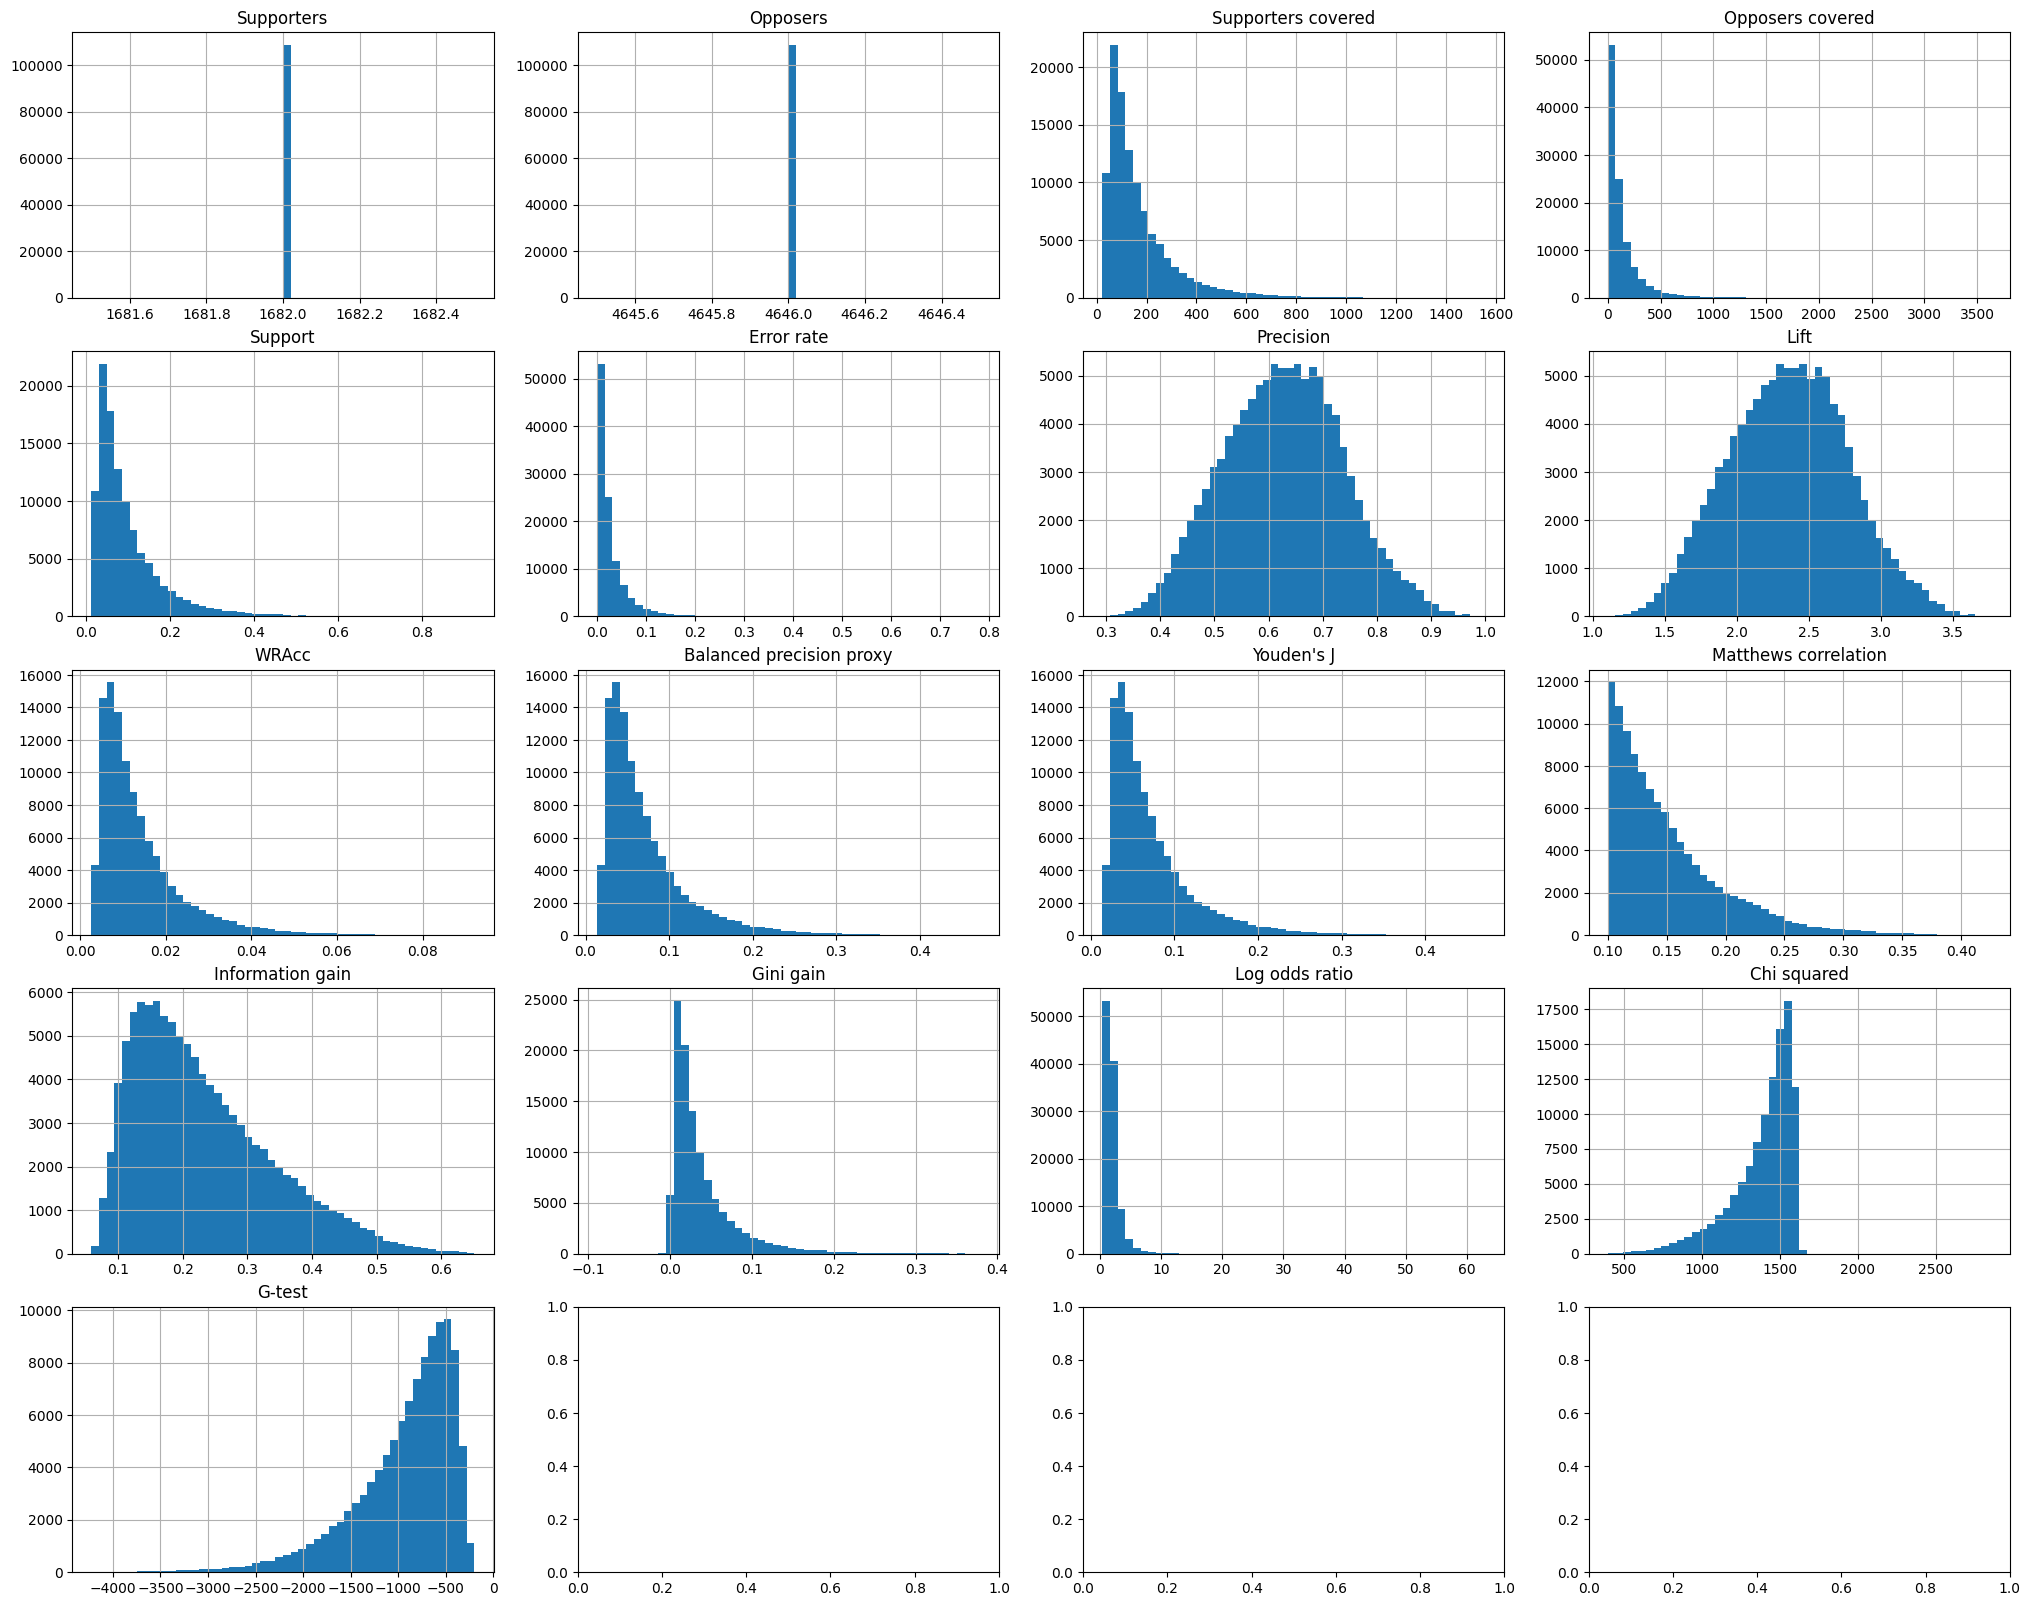

In [17]:
COLUMNS = [
    'Supporters', 'Opposers', 'Supporters covered', 'Opposers covered',
    'Support', 'Error rate', 'Precision', 'Lift',
    'WRAcc', 'Balanced precision proxy', 'Youden\'s J', 'Matthews correlation',
    'Information gain',	'Gini gain', 'Log odds ratio',	'Chi squared',
    'G-test'
]
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    scores[column].hist(ax = ax, bins = 50)

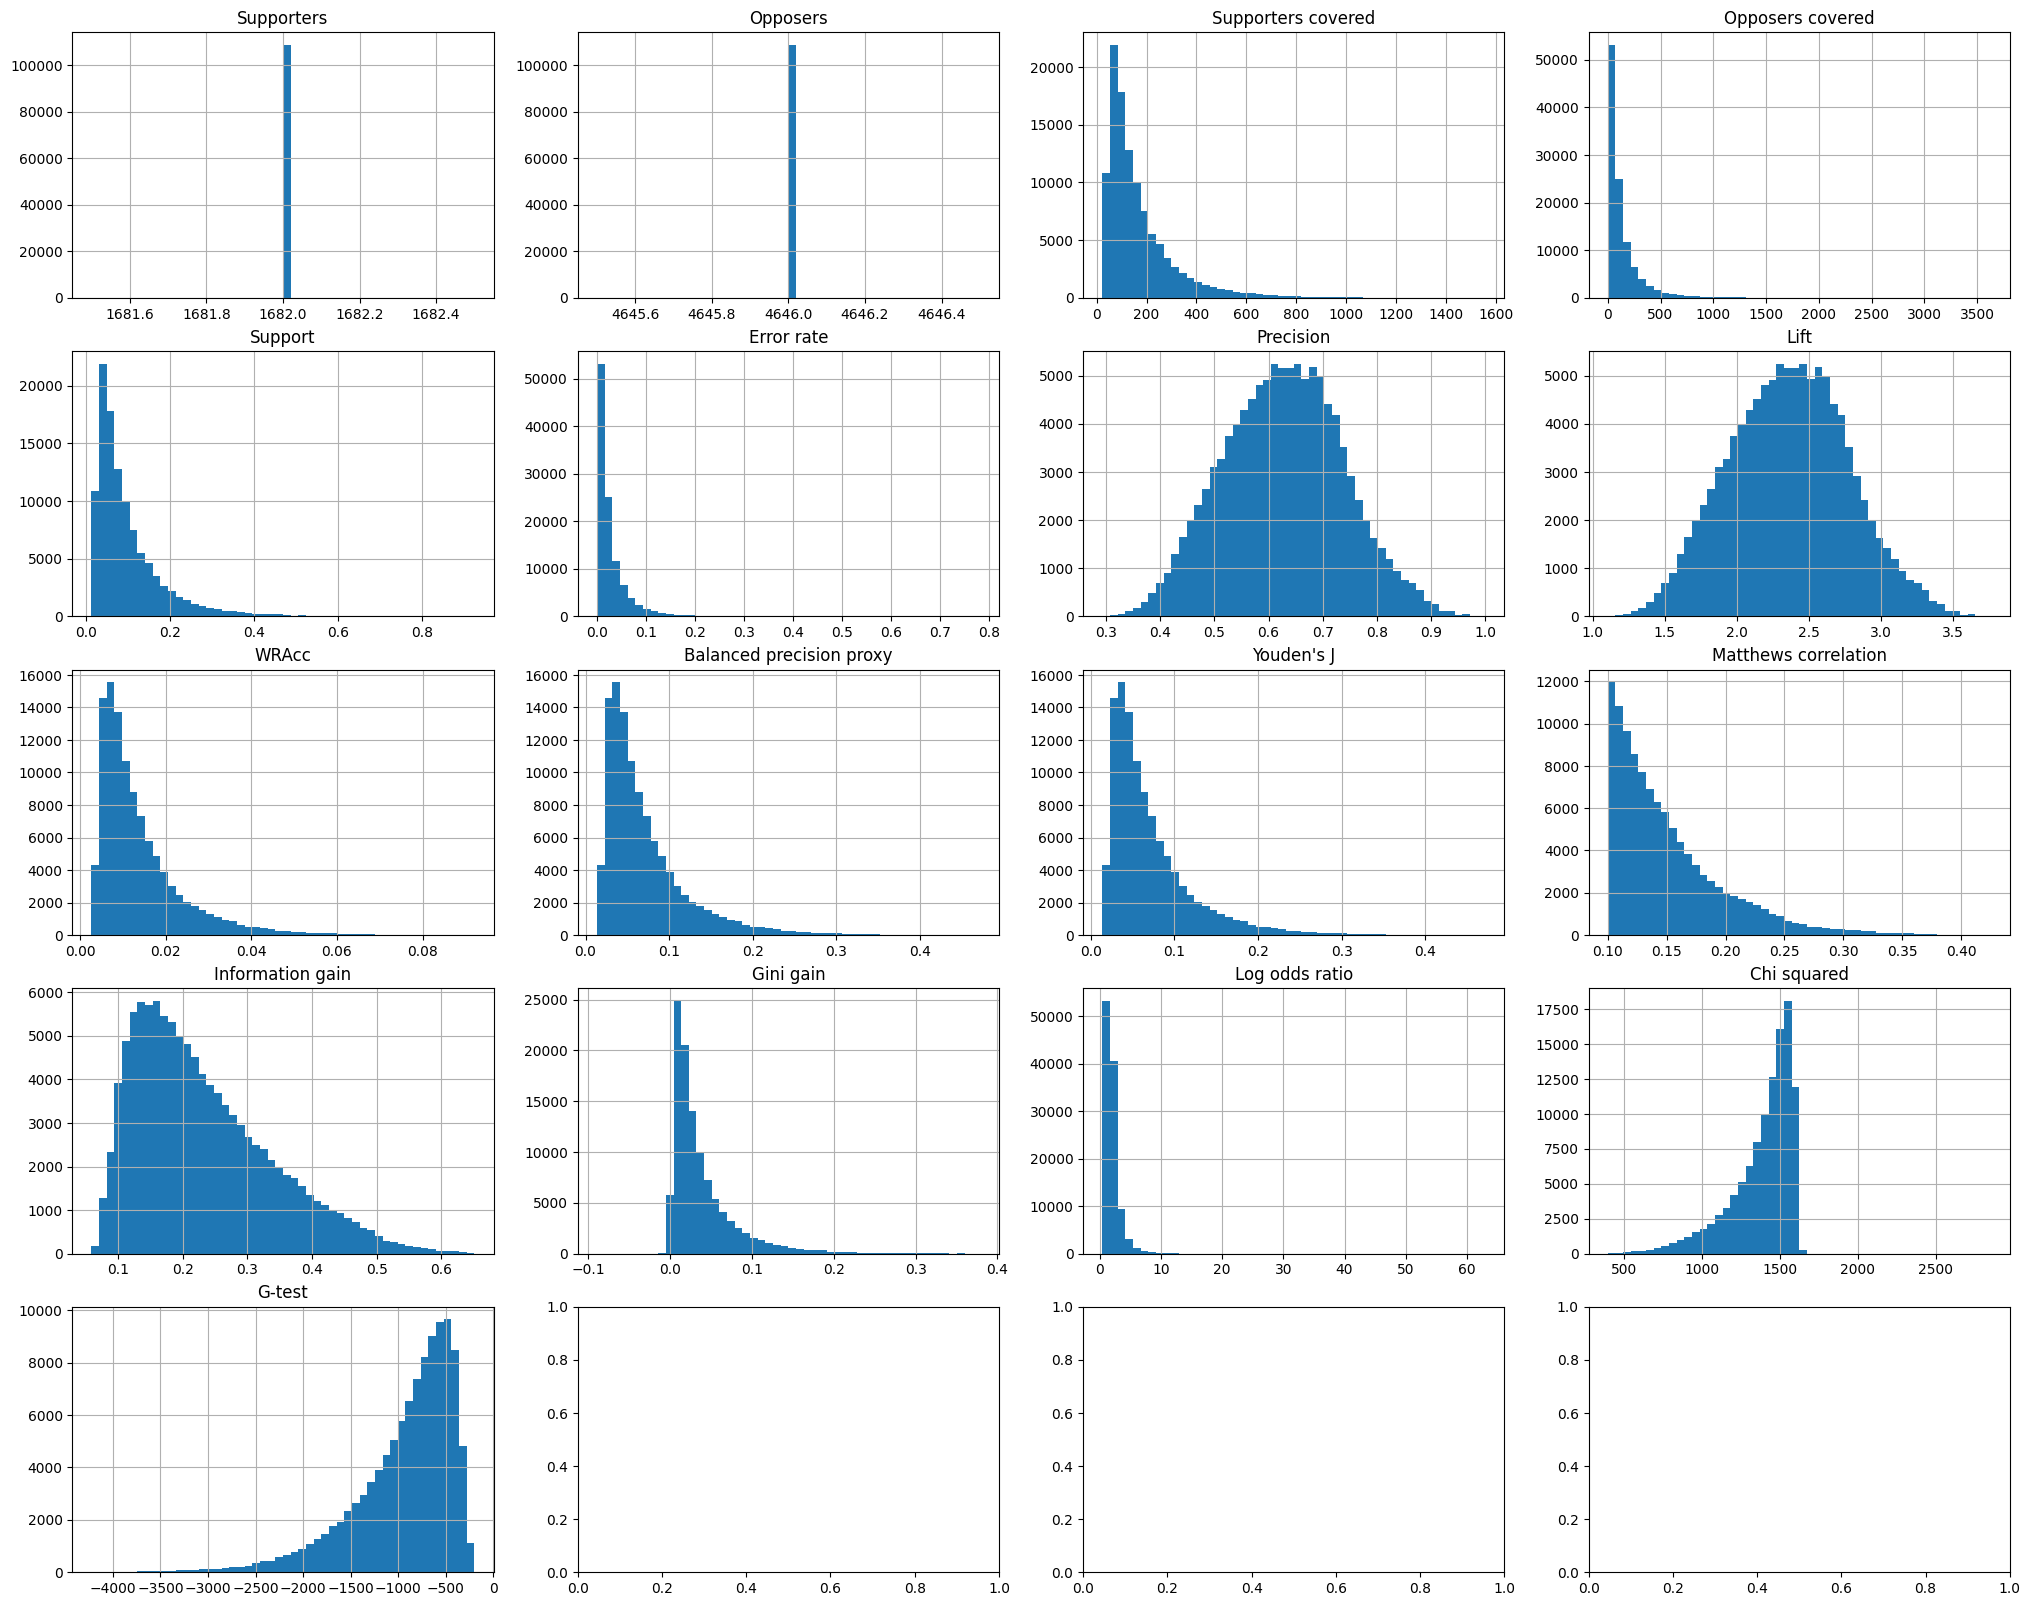

In [19]:
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    scores[scores["Type"] == "POSITIVE"][column].hist(ax = ax, bins = 50)

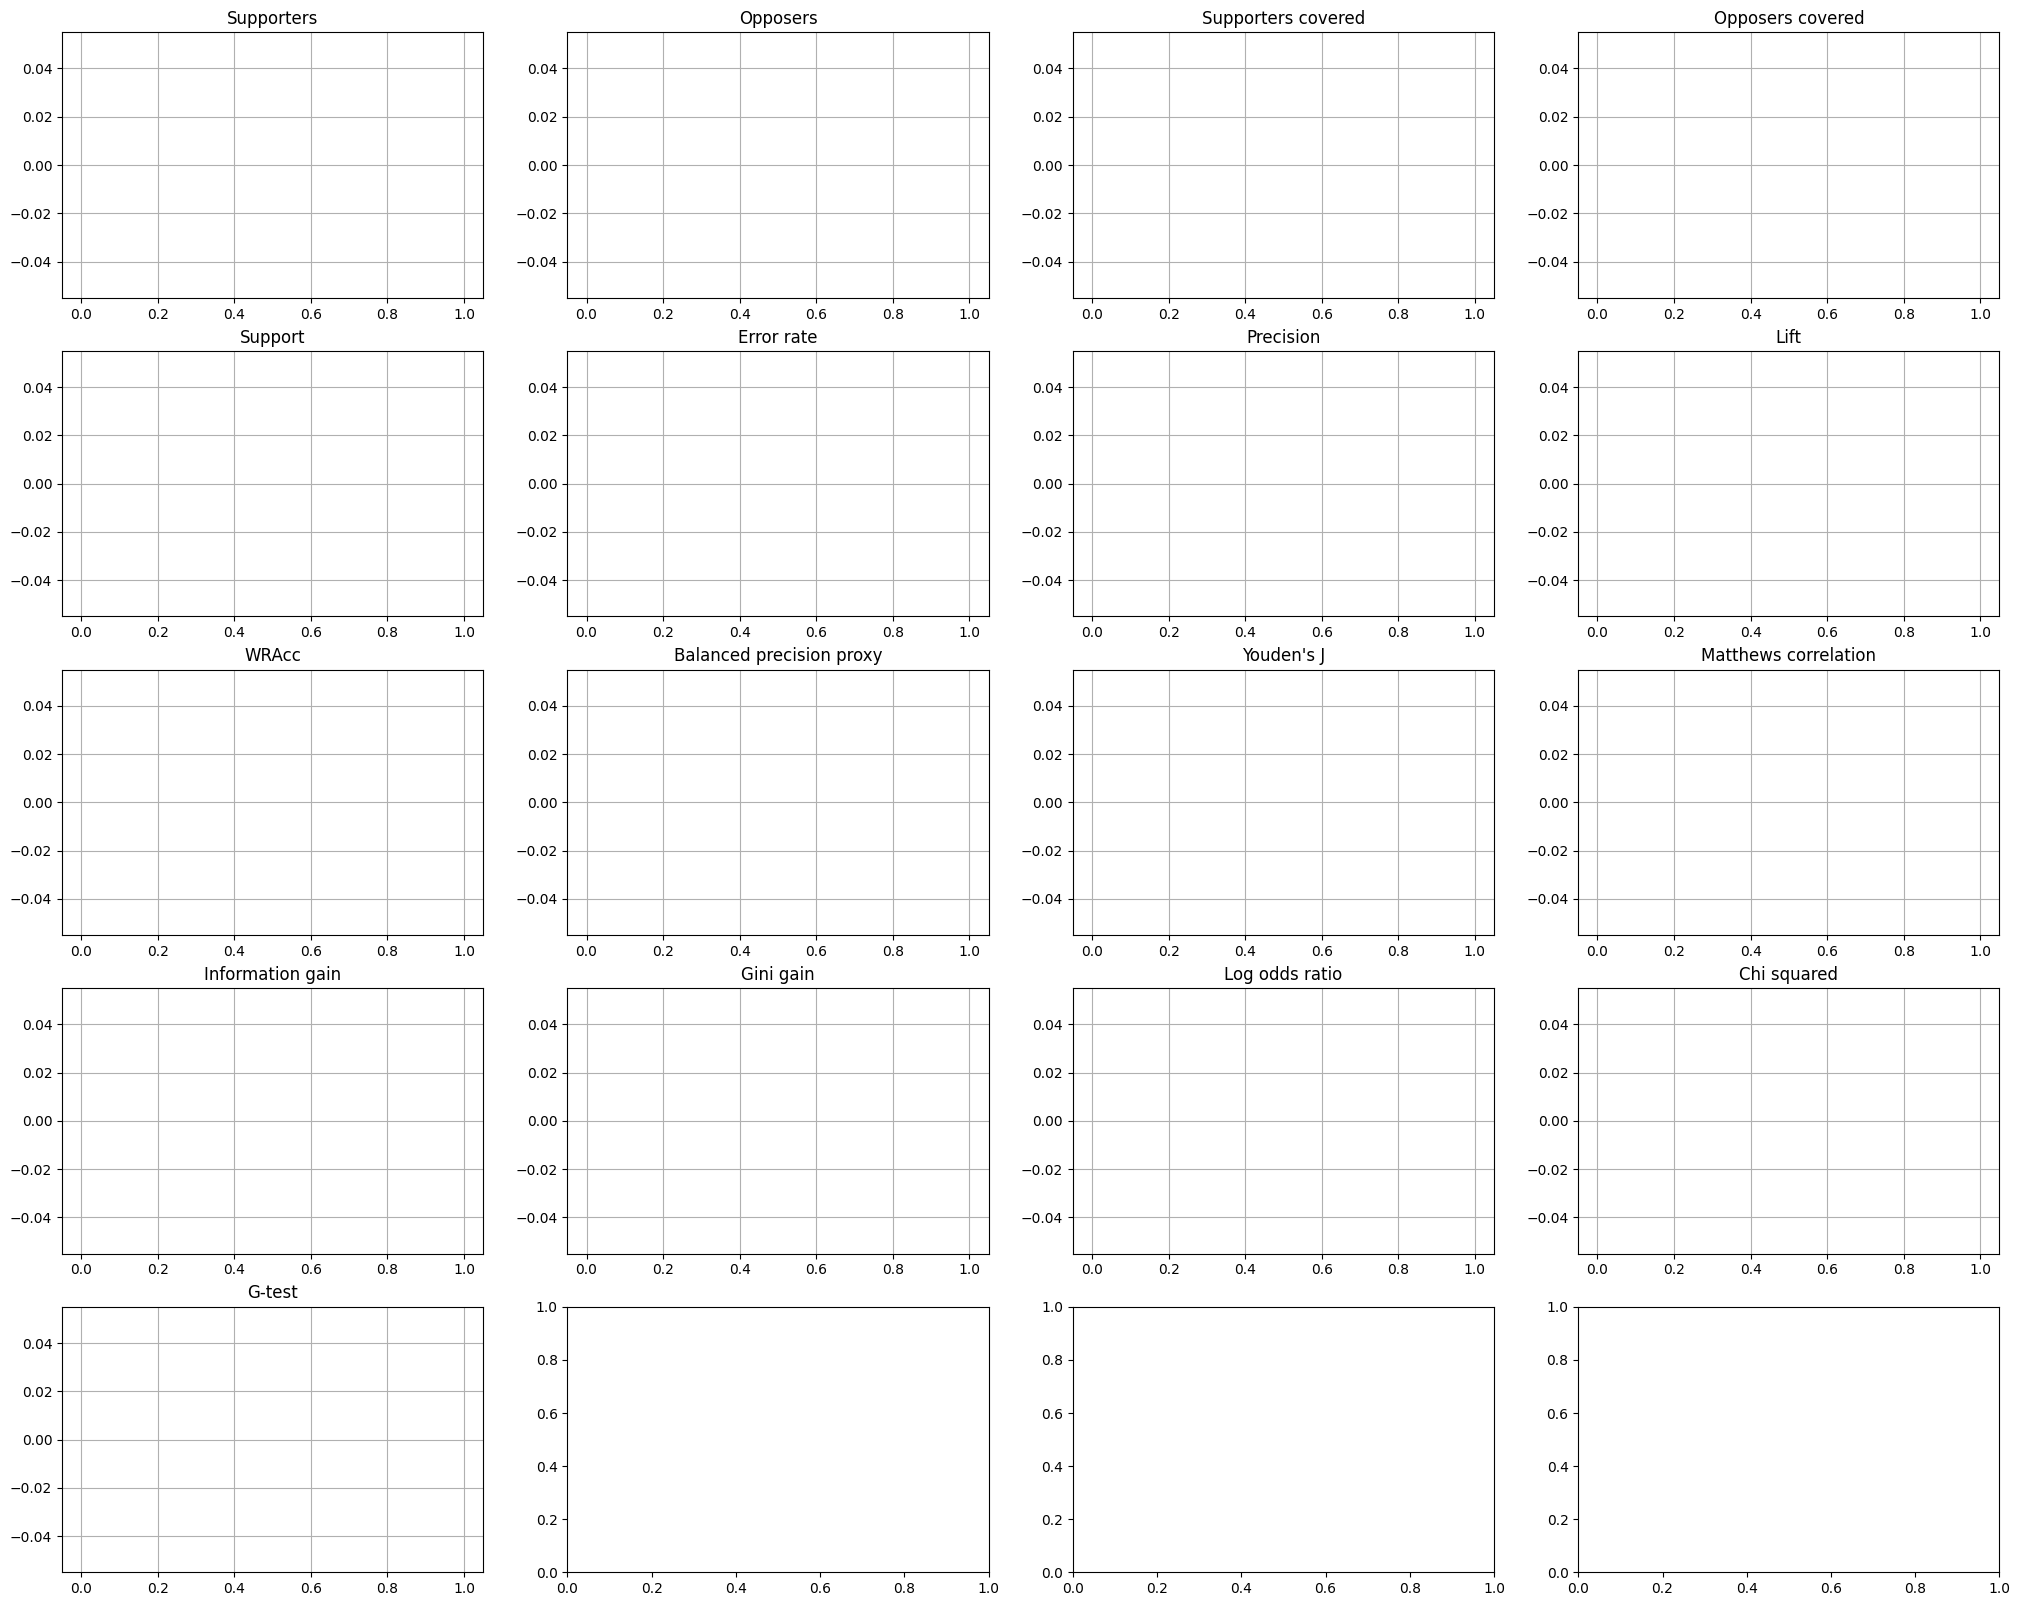

In [21]:
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    scores[scores["Type"] == "NEGATIVE"][column].hist(ax = ax, bins = 50)

## 5. Stability/robustness

I slightly change one object and see the results

In [23]:
idx = 502
example = X_test.iloc[idx]
example.to_frame().T

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__OnlineBackup_No,categorical__OnlineBackup_Yes,categorical__TechSupport_No,categorical__TechSupport_Yes,categorical__gender_Female,categorical__gender_Male,categorical__InternetService_DSL,...,categorical__StreamingMovies_No,categorical__StreamingMovies_Yes,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__DeviceProtection_No,categorical__DeviceProtection_Yes
502,72.0,19.55,1463.45,True,False,True,False,True,False,False,...,True,False,True,False,True,False,False,False,True,False


In [24]:
y_pred = classifier.predict(example.to_frame().T)
y_pred


100%|██████████| 1/1 [00:00<00:00, 692.59it/s]


array([[0.99802928, 0.00197072]])

In [25]:
y_test.iloc[idx]

np.False_

In [26]:
classifier.explain(example).display()

,Type,Supporters,Opposers,Supporters covered,Opposers covered
0,POSITIVE,1682,4646,5,6
1,POSITIVE,1682,4646,7,14
2,POSITIVE,1682,4646,341,874
3,POSITIVE,1682,4646,6,12
4,POSITIVE,1682,4646,5,13
...,...,...,...,...,...
3547,NEGATIVE,4646,1682,244,26
3548,NEGATIVE,4646,1682,25,0
3549,NEGATIVE,4646,1682,32,0
3550,NEGATIVE,4646,1682,74,1


Let's mess with some features

In [34]:
example_mess = example.copy().to_frame().T
example_mess['numeric__tenure'] = 10
example_mess['numeric__MonthlyCharges'] = 100
example_mess['numeric__TotalCharges'] = 500
example_mess

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__OnlineBackup_No,categorical__OnlineBackup_Yes,categorical__TechSupport_No,categorical__TechSupport_Yes,categorical__gender_Female,categorical__gender_Male,categorical__InternetService_DSL,...,categorical__StreamingMovies_No,categorical__StreamingMovies_Yes,categorical__OnlineSecurity_No,categorical__OnlineSecurity_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,categorical__DeviceProtection_No,categorical__DeviceProtection_Yes
502,10,100,500,True,False,True,False,True,False,False,...,True,False,True,False,True,False,False,False,True,False


In [36]:
y_pred = classifier.predict(example_mess)
y_pred


100%|██████████| 1/1 [00:00<00:00, 634.06it/s]


array([[0.64030612, 0.35969388]])

As we can see classifier less sure about negative class but still predict as negative despite I changed all 3 main features